In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report



In [5]:
df = pd.read_excel('heart_disease.xlsx', sheet_name=1)

df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [12]:
df.describe()


,age,trestbps,chol,thalch,oldpeak,num
count,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000
mean,53.425532,132.449173,202.652482,137.167849,0.891253,0.979905
std,9.099243,19.243667,111.654072,25.608434,1.093875,1.128783
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,177.250000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,225.000000,140.000000,0.500000,1.000000
75%,60.000000,140.000000,269.750000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [13]:
df.isna().sum()


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


In [14]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


In [15]:
df.select_dtypes(include="number").head()


,age,trestbps,chol,thalch,oldpeak,num
0,63,145,233,150,2.3,0
1,41,135,203,132,0.0,0
2,57,140,192,148,0.4,0
3,52,118,186,190,0.0,0
4,57,110,201,126,1.5,0


In [16]:
df = pd.read_excel("heart_disease.xlsx")

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df.head()


,age,age_in_years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...


In [17]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dtypes


,0
age,float64
age_in_years,float64


In [18]:
df = df.fillna(df.median())
df.isna().sum()


,0
age,12
age_in_years,12


In [19]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           0 non-null      float64
 1   age_in_years  0 non-null      float64
dtypes: float64(2)
memory usage: 324.0 bytes


,age,age_in_years
count,0.0,0.0
mean,NaN,NaN
std,NaN,NaN
min,NaN,NaN
25%,NaN,NaN
50%,NaN,NaN
75%,NaN,NaN
max,NaN,NaN


In [20]:
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()

df.head()

,age,age_in_years


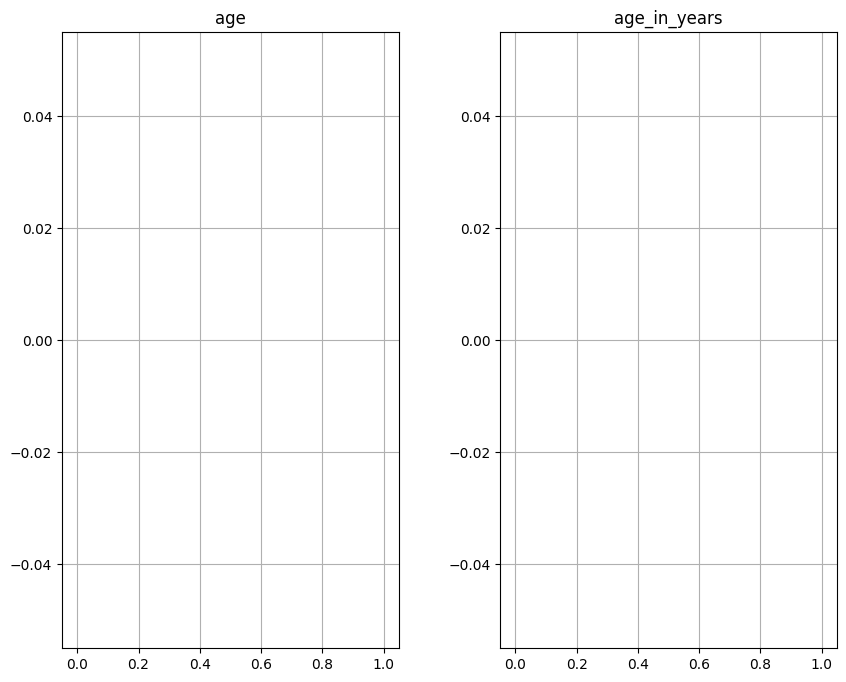

In [21]:
df.hist(figsize=(10,8))
plt.show()


/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


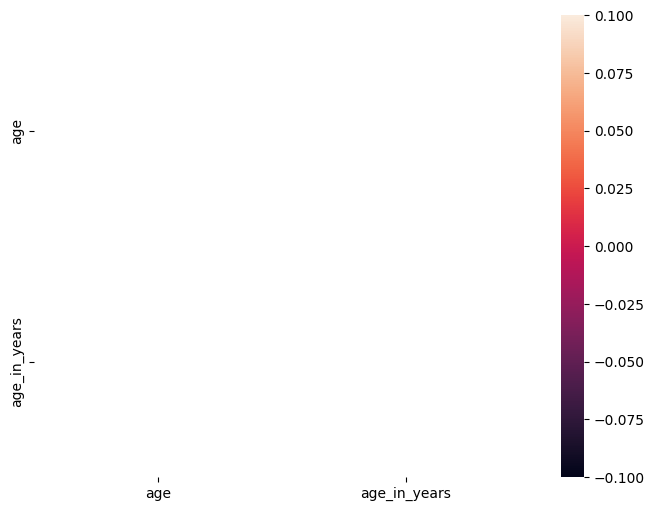

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.show()


Interview Questions

1. Common Hyperparameters in Decision Tree:

- max_depth: Controls depth of tree, prevents overfitting  
- min_samples_split: Minimum samples required to split a node  
- criterion: Method to measure split quality (gini or entropy)  

These parameters affect model performance and help control overfitting.

2. Difference between Label Encoding and One-Hot Encoding:

Label Encoding:
Assigns a unique number to each category (e.g., Male=0, Female=1)

One-Hot Encoding:
Creates separate binary columns for each category

Label encoding may introduce order, while one-hot encoding avoids this issue.